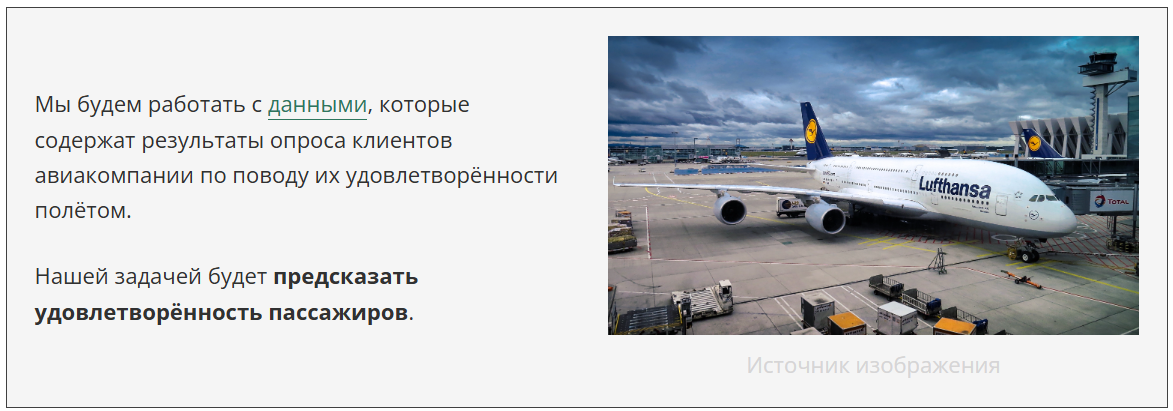

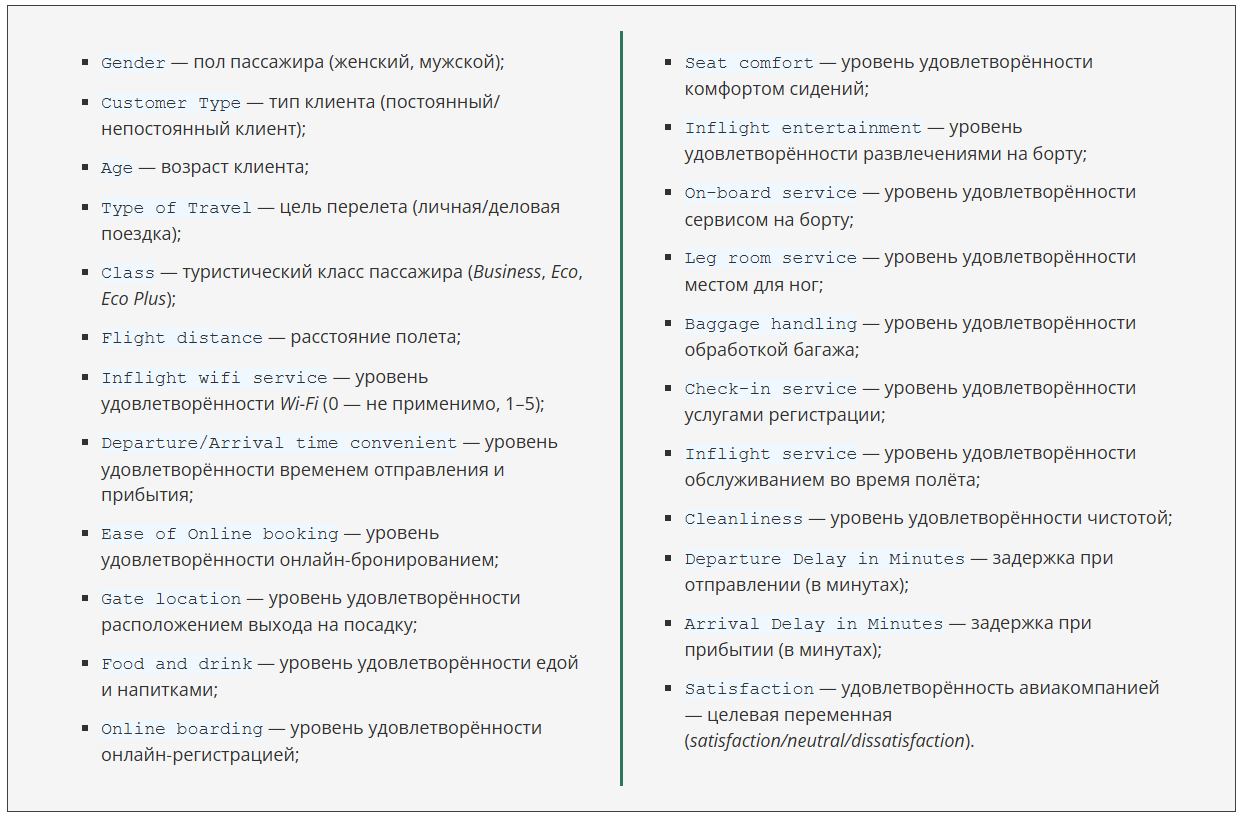

Перед тем как выполнить задания, вам необходимо установить несколько библиотек 

In [1]:
#!pip install xgboost
#!pip install catboost

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Метрики <b>f1_score</b> необходимо получать по обеим (обучающей и тестовой) выборкам.

In [2]:
# Загрузим данные
import pandas as pd
data = pd.read_csv('data\AirPass.csv')
data.drop(columns='Unnamed: 0', inplace=True)

**Задание 6.1**
Для начала сделаем небольшую предобработку данных. Сколько всего в данных пропущенных значений?

In [3]:
print(f'Всего в данных пропущенных значений: {data.isnull().sum().sum()}')

Всего в данных пропущенных значений: 310


**Задание 6.2**
Теперь давайте избавимся от найденных пропусков. Заполните их все медианными значениями. После этого вычислите среднее арифметическое для признака, отражающего задержку при прибытии в минутах. Ответ округлите до двух знаков после точки-разделителя.

In [4]:
df_data = data.copy()

df_data.fillna(df_data.median(), inplace=True)

print('Задержка при прибытии в минутах:',df_data['Arrival Delay in Minutes'].mean().round(2))

Задержка при прибытии в минутах: 15.13


C:\Users\User\AppData\Local\Temp\ipykernel_11940\2812969984.py:3: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_data.fillna(df_data.median(), inplace=True)


**Задание 6.3**
Проведём небольшой разведывательный анализ. Посмотрим, в каких категориях пассажиров превалировали удовлетворённые полетом клиенты.

1. Сравните удовлетворённость полётом мужчин и женщин. Выберите верное утверждение:

<Axes: xlabel='Gender,satisfaction'>

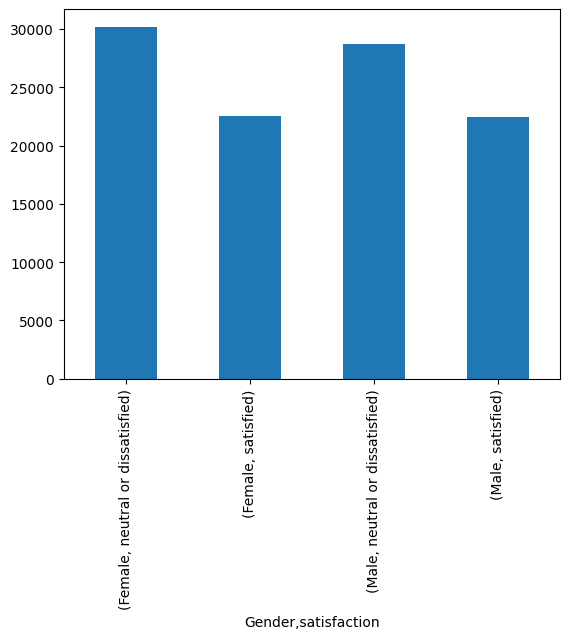

In [5]:
churn_df = df_data.copy()

churn_df = churn_df.groupby(by='Gender')['satisfaction'].value_counts()
churn_df.plot(kind='bar')

2. Теперь сравним категории пассажиров в зависимости от их цели поездки. Выберите все верные утверждения:

<Axes: xlabel='Type of Travel,satisfaction'>

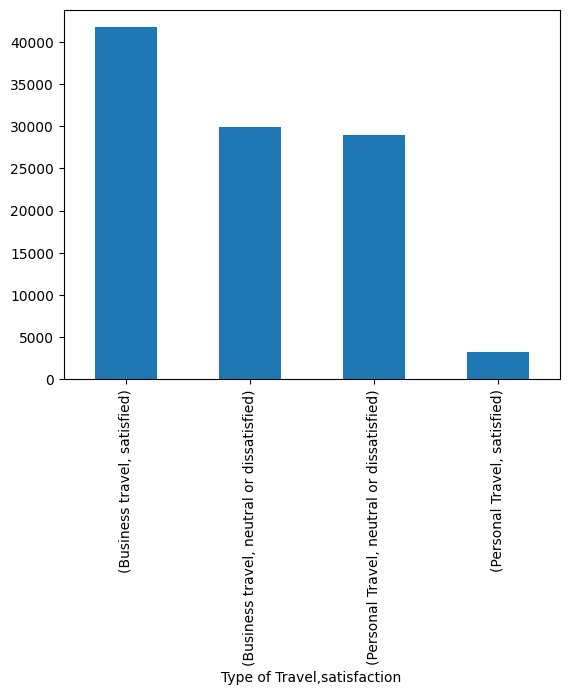

In [6]:
churn_df = df_data.copy()

churn_df = churn_df.groupby(by='Type of Travel')['satisfaction'].value_counts()
churn_df.plot(kind='bar')

3. В каком туристическом классе наибольший процент довольных клиентов?

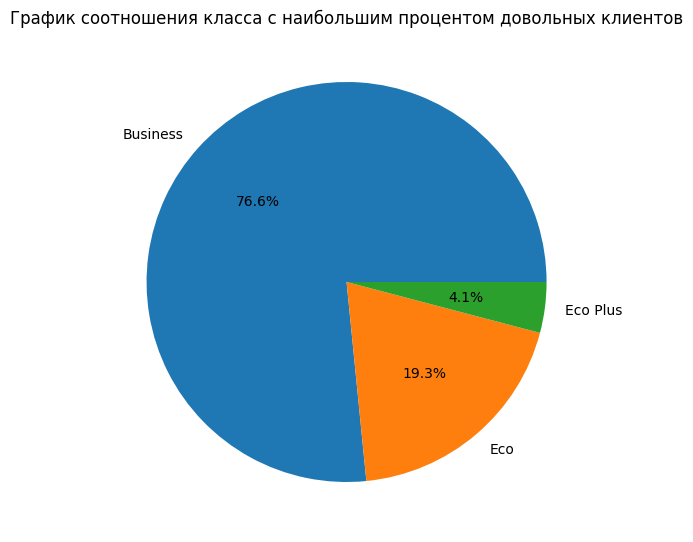

In [7]:
import matplotlib.pyplot as plt
churn_df = df_data.copy()

mask = churn_df['satisfaction'] == 'satisfied'
churn_df = churn_df['Class'][mask].value_counts()

fig = plt.figure(figsize=(5,5))
axes = fig.add_axes([0,0,1,1])
axes.pie(
    churn_df,
    labels=churn_df.index,
    autopct='%.1f%%'
)
title= axes.set_title('График соотношения класса с наибольшим процентом довольных клиентов')

Перекодируем часть бинарных признаков, чтобы использовать их при обучении:

In [8]:
df_data['satisfaction'] = df_data['satisfaction'].map({'neutral or dissatisfied':0 , 'satisfied':1})
df_data['Customer Type'] = df_data['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
df_data['Type of Travel'] = df_data['Type of Travel'].map({'Personal Travel':0, 'Business travel':1})
df_data['Gender'] = df_data['Gender'].map({'Male': 0, 'Female': 1})

**Задание 6.4**
Для остальных категориальных признаков создайте dummy-переменные. Сделайте это с помощью функции get_dummies() из библиотеки Pandas, параметры не меняйте. Сколько теперь признаков в данных (включая целевую переменную)?

In [9]:
df_dum = df_data.copy()

categorical_cols_object = df_data.select_dtypes(include=['object', 'category'])
df_dum = pd.get_dummies(df_dum, columns=[categorical_cols_object.columns[0]])

print(f'признаков в данных, включая целевую переменную: {len(df_dum.columns)}')

признаков в данных, включая целевую переменную: 26


**Задание 6.5**
Мы практически добрались до обучения модели. Разбейте данные на обучающую и тестовую выборки в соотношении 80/20, параметр random_state = 26. Сколько наблюдений попало в тестовую выборку?

In [10]:
from sklearn.model_selection import train_test_split

X = df_dum.drop(columns='satisfaction')
y = df_dum['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=26)
print(f'Наблюдений попало в тестовую выборку: {len(X_test.index)}')

Наблюдений попало в тестовую выборку: 20781


**Задание 6.6**
Теперь нам необходимо реализовать масштабирование данных. Для этого обучите на обучающей выборке метод StandardScaler() и с помощью него преобразуйте и обучающую, и тестовую выборки. Не забудьте, что целевую переменную обрабатывать не нужно.<br>
В качестве ответа введите самое первое значение из матрицы преобразованных признаков тестовой выборки. Округлите значение до двух знаков после точки-разделителя.

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Примечание</b>. Отметим, что если бы дальше мы работали только с деревьями, масштабирование бы не требовалось. Однако мы реализуем его, чтобы можно было обучать и другие модели и сравнивать полученные результаты.

In [11]:
from sklearn import preprocessing

#Инициализируем стандартизатор StandardScaler
scaler = preprocessing.StandardScaler()

#Производим стандартизацию
X_train_scaled = scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Составляем DataFrame из результата
features = X_train.columns
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

print(f'Первое значение из матрицы преобразованных признаков тестовой выборки: {X_test_scaled.iloc[0][0].round(2)}')

Первое значение из матрицы преобразованных признаков тестовой выборки: 0.94


**Задание 6.7**

Перейдём к обучению моделей. В качестве первой модели возьмём самую простую — логистическую регрессию. Мы делаем это для того, чтобы потом сравнивать с ней полученные результаты: так вы сможете выяснить, насколько ансамбли смогут улучшить точность прогноза.

Обучите логистическую регрессию с параметрами по умолчанию на наших данных. В качестве ответа введите значение метрики f1_score. Ответ округлите до трёх знаков после точки-разделителя.

In [12]:
from sklearn import linear_model
from sklearn import metrics
from sklearn.metrics import f1_score

#Создаём объект класса LogisticRegression
log_reg = linear_model.LogisticRegression(random_state=42)
#Обучаем модель, минизируя logloss
log_reg.fit(X_train_scaled, y_train)

# Делаем предсказание
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

print(f'Значение метрики f1_score на тренировочной выборке: {f1_score(y_train_pred, y_train):.3f}')
print(f'Значение метрики f1_score на тестовой выборке: {f1_score(y_test_pred, y_test):.3f}')

Значение метрики f1_score на тренировочной выборке: 0.854
Значение метрики f1_score на тестовой выборке: 0.855


**Задание 6.8**
Теперь перейдём к бустингу. Начнём с обучения первой модели — AdaBoost. В качестве базовой модели для неё возьмите решающее дерево с параметром random_state = 26.

Обучите AdaBoost, зафиксировав random_state со значением 26 и задав темп обучения 0.01. В качестве ответа введите значение метрики f1_score. Ответ округлите до трёх знаков после точки-разделителя.

In [13]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

#Создаём объект класса AdaBoostClassifier
model_ada = AdaBoostClassifier(DecisionTreeClassifier(random_state=26),random_state=26,learning_rate=0.01)

#Обучаем модель
model_ada.fit(X_train_scaled, y_train)

# Делаем предсказание
y_train_pred = model_ada.predict(X_train_scaled)
y_test_pred = model_ada.predict(X_test_scaled)

print(f'Значение метрики f1_score на тренировочной выборке: {f1_score(y_train_pred, y_train):.3f}')
print(f'Значение метрики f1_score на тестовой выборке: {f1_score(y_test_pred, y_test):.3f}')

Значение метрики f1_score на тренировочной выборке: 1.000
Значение метрики f1_score на тестовой выборке: 0.940


**Задание 6.9**
Перейдем к следующему алгоритму — градиентному бустингу.

Будем настраивать количество деревьев и темп обучения, делая перебор по следующей сетке:

params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}
Используйте для поиска оптимальных параметров GridSearchCV, а для ускорения работы алгоритма задайте параметр кросс-валидации, равный 3.

Какое наибольшее значение метрики f1_score получилось? Ответ округлите до трёх знаков после точки-разделителя.

In [15]:
from sklearn import ensemble
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import make_scorer

params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}

gs = GridSearchCV(
    estimator=ensemble.GradientBoostingClassifier(), #генератор случайных чисел
    param_grid=params,
    scoring=make_scorer(f1_score),
    verbose=5,
    cv=3,
)

gs.fit(X_train_scaled, y_train)
 
print("Лучшие гиперпараметры:", gs.best_params_)
print("Лучшее значение метрики:", gs.best_score_)


y_train_pred = gs.predict(X_train_scaled)
y_test_pred = gs.predict(X_test_scaled)

print(f'Значение метрики f1_score на тренировочной выборке: {f1_score(y_train_pred, y_train):.3f}')
print(f'Значение метрики f1_score на тестовой выборке: {f1_score(y_test_pred, y_test):.3f}')

**Задание 6.10**
Обучите алгоритм XGBoost. Так как он достаточно мощный «из коробки», определите его с параметрами по умолчанию, только задайте random_state = 26. Какое значение метрики f1_score получилось? Ответ округлите до трёх знаков после точки-разделителя.

In [14]:
from xgboost import XGBClassifier

# Train in the clear and quantize the weights
model_xgb = XGBClassifier(random_state = 26)
model_xgb.fit(X_train_scaled, y_train)

# Simulate the predictions
y_test_pred = model_xgb.predict(X_test_scaled)

#print(f'Значение метрики f1_score на тренировочной выборке: {f1_score(y_train_pred, y_train):.3f}')
print(f'Значение метрики f1_score на тестовой выборке: {f1_score(y_test_pred, y_test):.3f}')

Значение метрики f1_score на тестовой выборке: 0.957


**Задание 6.11**
Обучите алгоритм CatBoost. Как и XGBoost, будем обучать его с настройками по умолчанию и заданным random_state = 26. Какое значение метрики f1_score получилось? Ответ округлите до трёх знаков после точки-разделителя.

In [15]:
from catboost import CatBoostClassifier

# Train in the clear and quantize the weights
model_catBC = CatBoostClassifier(random_state = 26)
model_catBC.fit(X_train_scaled, y_train)

# Simulate the predictions
y_test_pred = model_catBC.predict(X_test_scaled)

#print(f'Значение метрики f1_score на тренировочной выборке: {f1_score(y_train_pred, y_train):.3f}')
print(f'Значение метрики f1_score на тестовой выборке: {f1_score(y_test_pred, y_test):.3f}')

Learning rate set to 0.068023
0:	learn: 0.6018254	total: 237ms	remaining: 3m 56s
1:	learn: 0.5020788	total: 304ms	remaining: 2m 31s
2:	learn: 0.4472506	total: 363ms	remaining: 2m
3:	learn: 0.4028683	total: 427ms	remaining: 1m 46s
4:	learn: 0.3674742	total: 501ms	remaining: 1m 39s
5:	learn: 0.3397838	total: 564ms	remaining: 1m 33s
6:	learn: 0.3121236	total: 630ms	remaining: 1m 29s
7:	learn: 0.2917493	total: 694ms	remaining: 1m 26s
8:	learn: 0.2749031	total: 796ms	remaining: 1m 27s
9:	learn: 0.2575194	total: 900ms	remaining: 1m 29s
10:	learn: 0.2473688	total: 995ms	remaining: 1m 29s
11:	learn: 0.2377536	total: 1.06s	remaining: 1m 27s
12:	learn: 0.2279307	total: 1.13s	remaining: 1m 25s
13:	learn: 0.2212511	total: 1.19s	remaining: 1m 24s
14:	learn: 0.2100355	total: 1.28s	remaining: 1m 24s
15:	learn: 0.2025734	total: 1.35s	remaining: 1m 22s
16:	learn: 0.1942301	total: 1.41s	remaining: 1m 21s
17:	learn: 0.1877938	total: 1.48s	remaining: 1m 20s
18:	learn: 0.1832382	total: 1.56s	remaining: 1m 

158:	learn: 0.0921441	total: 12.8s	remaining: 1m 7s
159:	learn: 0.0920109	total: 12.9s	remaining: 1m 7s
160:	learn: 0.0918072	total: 13s	remaining: 1m 7s
161:	learn: 0.0917630	total: 13.1s	remaining: 1m 7s
162:	learn: 0.0916563	total: 13.1s	remaining: 1m 7s
163:	learn: 0.0915352	total: 13.2s	remaining: 1m 7s
164:	learn: 0.0913332	total: 13.3s	remaining: 1m 7s
165:	learn: 0.0911235	total: 13.3s	remaining: 1m 7s
166:	learn: 0.0909360	total: 13.4s	remaining: 1m 6s
167:	learn: 0.0907373	total: 13.5s	remaining: 1m 6s
168:	learn: 0.0905481	total: 13.6s	remaining: 1m 6s
169:	learn: 0.0903530	total: 13.7s	remaining: 1m 6s
170:	learn: 0.0902766	total: 13.7s	remaining: 1m 6s
171:	learn: 0.0900627	total: 13.8s	remaining: 1m 6s
172:	learn: 0.0899773	total: 13.9s	remaining: 1m 6s
173:	learn: 0.0899037	total: 13.9s	remaining: 1m 6s
174:	learn: 0.0898765	total: 14s	remaining: 1m 6s
175:	learn: 0.0895876	total: 14.1s	remaining: 1m 6s
176:	learn: 0.0894685	total: 14.2s	remaining: 1m 5s
177:	learn: 0.08

319:	learn: 0.0779769	total: 24.4s	remaining: 51.8s
320:	learn: 0.0779506	total: 24.4s	remaining: 51.6s
321:	learn: 0.0779211	total: 24.5s	remaining: 51.5s
322:	learn: 0.0778426	total: 24.5s	remaining: 51.4s
323:	learn: 0.0777700	total: 24.6s	remaining: 51.4s
324:	learn: 0.0777144	total: 24.7s	remaining: 51.3s
325:	learn: 0.0776575	total: 24.7s	remaining: 51.2s
326:	learn: 0.0776023	total: 24.8s	remaining: 51.1s
327:	learn: 0.0775654	total: 24.9s	remaining: 51s
328:	learn: 0.0775459	total: 24.9s	remaining: 50.9s
329:	learn: 0.0775045	total: 25s	remaining: 50.8s
330:	learn: 0.0774829	total: 25.1s	remaining: 50.7s
331:	learn: 0.0773886	total: 25.1s	remaining: 50.6s
332:	learn: 0.0773355	total: 25.2s	remaining: 50.4s
333:	learn: 0.0772632	total: 25.2s	remaining: 50.3s
334:	learn: 0.0772082	total: 25.3s	remaining: 50.3s
335:	learn: 0.0771226	total: 25.4s	remaining: 50.2s
336:	learn: 0.0770861	total: 25.5s	remaining: 50.1s
337:	learn: 0.0770018	total: 25.5s	remaining: 50s
338:	learn: 0.0769

479:	learn: 0.0708595	total: 34.4s	remaining: 37.2s
480:	learn: 0.0708365	total: 34.4s	remaining: 37.1s
481:	learn: 0.0708160	total: 34.5s	remaining: 37.1s
482:	learn: 0.0707703	total: 34.5s	remaining: 37s
483:	learn: 0.0707147	total: 34.6s	remaining: 36.9s
484:	learn: 0.0707065	total: 34.7s	remaining: 36.8s
485:	learn: 0.0706694	total: 34.7s	remaining: 36.7s
486:	learn: 0.0706340	total: 34.8s	remaining: 36.6s
487:	learn: 0.0706052	total: 34.8s	remaining: 36.5s
488:	learn: 0.0705491	total: 34.9s	remaining: 36.5s
489:	learn: 0.0705111	total: 35s	remaining: 36.4s
490:	learn: 0.0704995	total: 35s	remaining: 36.3s
491:	learn: 0.0704564	total: 35.1s	remaining: 36.2s
492:	learn: 0.0704498	total: 35.1s	remaining: 36.1s
493:	learn: 0.0704407	total: 35.2s	remaining: 36.1s
494:	learn: 0.0704236	total: 35.3s	remaining: 36s
495:	learn: 0.0703743	total: 35.3s	remaining: 35.9s
496:	learn: 0.0703507	total: 35.4s	remaining: 35.8s
497:	learn: 0.0703434	total: 35.4s	remaining: 35.7s
498:	learn: 0.070298

639:	learn: 0.0657075	total: 44.2s	remaining: 24.8s
640:	learn: 0.0656911	total: 44.2s	remaining: 24.8s
641:	learn: 0.0656414	total: 44.3s	remaining: 24.7s
642:	learn: 0.0656061	total: 44.4s	remaining: 24.6s
643:	learn: 0.0655822	total: 44.4s	remaining: 24.6s
644:	learn: 0.0655544	total: 44.5s	remaining: 24.5s
645:	learn: 0.0655241	total: 44.5s	remaining: 24.4s
646:	learn: 0.0655028	total: 44.6s	remaining: 24.3s
647:	learn: 0.0654764	total: 44.7s	remaining: 24.3s
648:	learn: 0.0654460	total: 44.7s	remaining: 24.2s
649:	learn: 0.0654302	total: 44.8s	remaining: 24.1s
650:	learn: 0.0654156	total: 44.8s	remaining: 24s
651:	learn: 0.0653929	total: 44.9s	remaining: 24s
652:	learn: 0.0653499	total: 45s	remaining: 23.9s
653:	learn: 0.0653414	total: 45s	remaining: 23.8s
654:	learn: 0.0653181	total: 45.1s	remaining: 23.7s
655:	learn: 0.0652767	total: 45.1s	remaining: 23.7s
656:	learn: 0.0652621	total: 45.2s	remaining: 23.6s
657:	learn: 0.0652513	total: 45.3s	remaining: 23.5s
658:	learn: 0.065214

798:	learn: 0.0616345	total: 54.1s	remaining: 13.6s
799:	learn: 0.0616236	total: 54.2s	remaining: 13.5s
800:	learn: 0.0616215	total: 54.2s	remaining: 13.5s
801:	learn: 0.0615951	total: 54.3s	remaining: 13.4s
802:	learn: 0.0615716	total: 54.3s	remaining: 13.3s
803:	learn: 0.0615338	total: 54.4s	remaining: 13.3s
804:	learn: 0.0615076	total: 54.5s	remaining: 13.2s
805:	learn: 0.0614836	total: 54.5s	remaining: 13.1s
806:	learn: 0.0614615	total: 54.6s	remaining: 13.1s
807:	learn: 0.0614479	total: 54.6s	remaining: 13s
808:	learn: 0.0614119	total: 54.7s	remaining: 12.9s
809:	learn: 0.0613897	total: 54.8s	remaining: 12.8s
810:	learn: 0.0613741	total: 54.8s	remaining: 12.8s
811:	learn: 0.0613520	total: 54.9s	remaining: 12.7s
812:	learn: 0.0613247	total: 55s	remaining: 12.6s
813:	learn: 0.0612833	total: 55s	remaining: 12.6s
814:	learn: 0.0612590	total: 55.1s	remaining: 12.5s
815:	learn: 0.0612523	total: 55.2s	remaining: 12.4s
816:	learn: 0.0612287	total: 55.2s	remaining: 12.4s
817:	learn: 0.0612

958:	learn: 0.0579329	total: 1m 4s	remaining: 2.76s
959:	learn: 0.0579038	total: 1m 4s	remaining: 2.69s
960:	learn: 0.0578819	total: 1m 4s	remaining: 2.63s
961:	learn: 0.0578108	total: 1m 4s	remaining: 2.56s
962:	learn: 0.0578021	total: 1m 4s	remaining: 2.49s
963:	learn: 0.0578007	total: 1m 4s	remaining: 2.42s
964:	learn: 0.0577727	total: 1m 4s	remaining: 2.36s
965:	learn: 0.0577443	total: 1m 5s	remaining: 2.29s
966:	learn: 0.0577310	total: 1m 5s	remaining: 2.22s
967:	learn: 0.0577114	total: 1m 5s	remaining: 2.15s
968:	learn: 0.0576906	total: 1m 5s	remaining: 2.09s
969:	learn: 0.0576743	total: 1m 5s	remaining: 2.02s
970:	learn: 0.0576533	total: 1m 5s	remaining: 1.95s
971:	learn: 0.0576330	total: 1m 5s	remaining: 1.88s
972:	learn: 0.0576146	total: 1m 5s	remaining: 1.82s
973:	learn: 0.0575916	total: 1m 5s	remaining: 1.75s
974:	learn: 0.0575637	total: 1m 5s	remaining: 1.68s
975:	learn: 0.0575354	total: 1m 5s	remaining: 1.61s
976:	learn: 0.0575108	total: 1m 5s	remaining: 1.55s
977:	learn: 

**Задание 6.12**
Выведите матрицу ошибок для алгоритма, который получил наилучшие показатели качества модели на обучающей выборке (будем считать, что оцениваем по f1_score). Матрица ошибок выводится в следующем формате: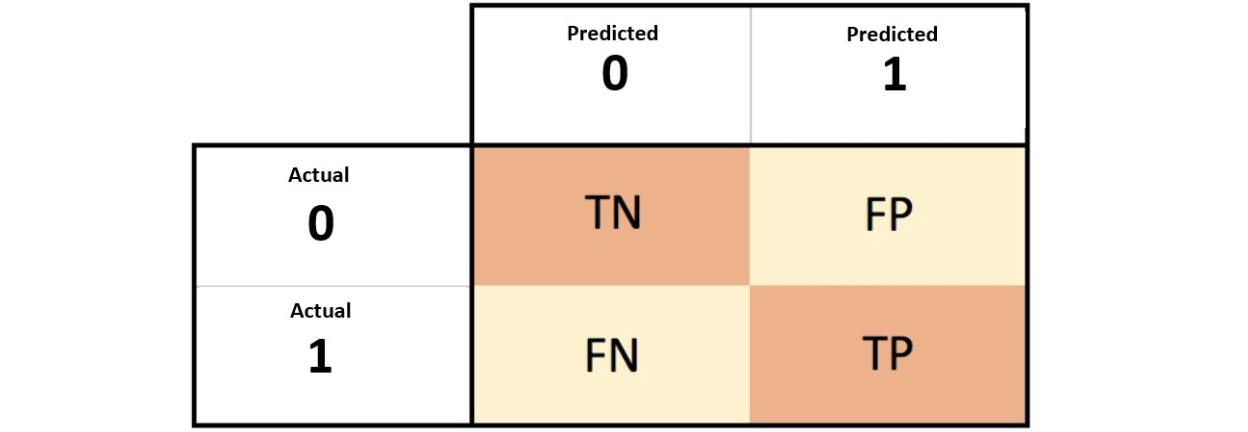

Значения в матрице ошибок переведите в проценты от общего числа наблюдений в обучающей выборке и округлите до целых.

<p style="background: #CCFFCC; border:1px black  solid; text-align: left; padding: 10px"><b>Подсказка</b>. Для того чтобы построить матрицу ошибок в CatBoost, необходимо использовать следующий шаблон:
get_confusion_matrix(модель, Pool(признаки обучающей выборки, целевая переменная обучающей выборки))

Более подробно построение матрицы ошибок можно изучить в [документации](https://catboost.ai/en/docs/concepts/python-reference_utils_get_confusion_matrix).

In [28]:
from catboost import Pool, CatBoostClassifier
from catboost.utils import get_confusion_matrix


cm = get_confusion_matrix(model_catBC, Pool(X_train_scaled, y_train))
print('Значения в матрице ошибок в процентах', 
      ((cm/X_train_scaled.shape[0])*100).round())

Значения в матрице ошибок в процентах [[56.  1.]
 [ 2. 42.]]


**Задание 6.13**
Оцените важность признаков для модели из предыдущего задания. Отметьте признак, который оказывает наибольшее влияние на значение целевой переменной:

In [35]:
feature_names = [x for x in X_train_scaled if x != 'satisfaction']
pd.DataFrame({'feat': feature_names,
              'coef': model_catBC.feature_importances_}).sort_values(by='coef', ascending=False).head(3)

,feat,coef
6,Inflight wifi service,25.260967
4,Type of Travel,18.532444
2,Customer Type,7.373753


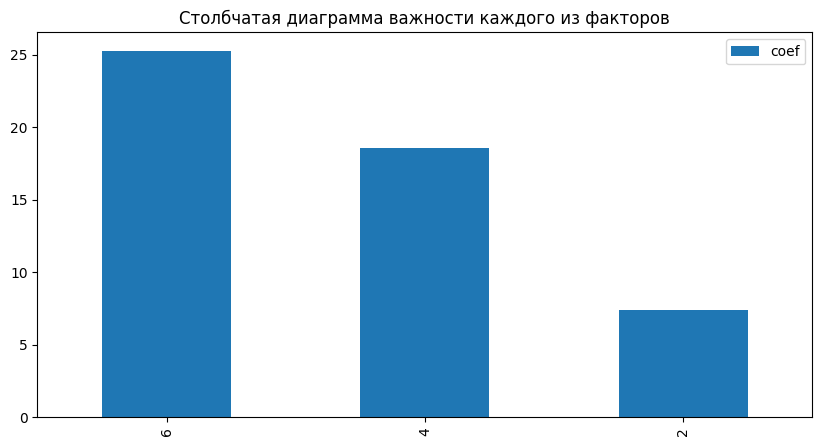

In [49]:
# Нарисуем столбчатую диаграмму
churn_df = pd.DataFrame({'feat': feature_names,
              'coef': model_catBC.feature_importances_}).sort_values(by='coef', ascending=False).head(3).plot(kind='bar', figsize=(10, 5), title='Столбчатая диаграмма важности каждого из факторов')
